In [44]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from ast import literal_eval

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:literal_eval(x) if pd.notna(x) else x)

In [11]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
df_DA = df_DA.explode('job_skills')


In [17]:
df_DA_scatter = df_DA.groupby('job_skills').agg(
    job_count = ('job_skills','count'),
    median_salary = ('salary_year_avg','median')
)
df_DA_scatter = df_DA_scatter.sort_values(by='job_count',ascending=False).head(10)
df_DA_scatter

,job_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


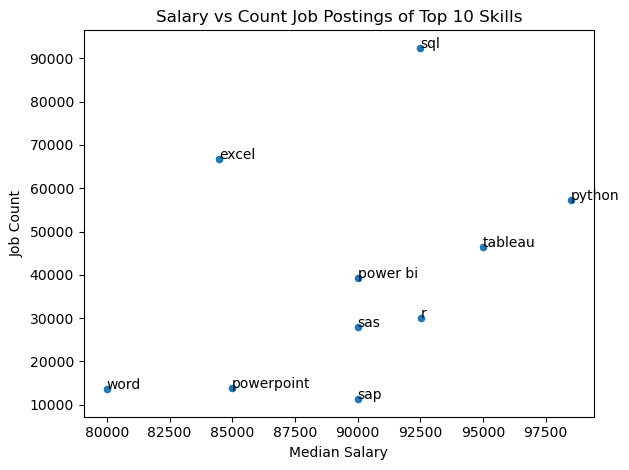

In [21]:
df_DA_scatter.plot(kind='scatter',x='median_salary',y='job_count')
plt.title('Salary vs Count Job Postings of Top 10 Skills')
plt.xlabel('Median Salary')
plt.ylabel('Job Count')
for i,title in enumerate(df_DA_scatter.index):
    plt.text(df_DA_scatter['median_salary'].iloc[i],df_DA_scatter['job_count'].iloc[i],title)
plt.tight_layout()
plt.show()